In [ ]:
!apt-get install -y fluidsynth
!pip install -q music21 pretty_midi midi2audio tensorflow keras

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fluid-soundfont-gm gsettings-desktop-schemas libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libdouble-conversion3 libevdev2
  libfluidsynth3 libgtk-3-0 libgtk-3-bin libgtk-3-common libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5
  librsvg2-common libwacom-bin libwacom-common libwacom9 libxcb-icccm4
  libxcb-image0 libxcb-keysyms1 libxcb-render-util0 libxcb-util1
  libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 qsynth qt5-gtk-platformtheme
  qttranslations5-l10n session-migration timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs gvfs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  at-spi2-core fluid-soundfont

In [ ]:
import os
import json
import numpy as np
from pathlib import Path
from music21 import instrument, note, chord, stream
from tensorflow.keras.models import load_model
from midi2audio import FluidSynth

# Directorios base
BASE_DIR = Path("/content/melody_project")
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "output"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Carpetas listas:")
print("DATA:", DATA_DIR)
print("MODELS:", MODELS_DIR)
print("OUTPUT:", OUTPUT_DIR)


Carpetas listas:
DATA: /content/melody_project/data
MODELS: /content/melody_project/models
OUTPUT: /content/melody_project/output


##Cargar el modelo entrenado en el colab previo.

In [ ]:
def load_model_and_vocab(prefix):

    # Rutas
    model_path_normal = MODELS_DIR / f"model_{prefix}.keras"
    model_path_embed = MODELS_DIR / f"model_{prefix}_embed.keras"
    vocab_path = DATA_DIR / f"{prefix}_notas_unicas.json"
    notas_path = DATA_DIR / f"{prefix}_notas.npy"

    # Detectar cuál modelo usar
    if model_path_embed.exists():
        model_path = model_path_embed
        use_embedding = True

    elif model_path_normal.exists():
        model_path = model_path_normal
        use_embedding = False

    else:
        raise FileNotFoundError(
            f"No se encontró ningún modelo para '{prefix}'.\n"
        )

    # Cargar modelo con el path correcto
    model = load_model(model_path)

    # Cargar vocabulario y notas
    with open(vocab_path, "r") as f:
        unique_notes = json.load(f)
    notas = np.load(notas_path, allow_pickle=True)

    note_to_int = {n: i for i, n in enumerate(unique_notes)}
    int_to_note = {i: n for n, i in note_to_int.items()}

    print(f"Vocabulario: {len(unique_notes)} notas únicas")
    return model, unique_notes, note_to_int, int_to_note, notas, use_embedding


##Generar las notas con el modelo y el vocabulario

In [ ]:
def generate_notes(model, note_to_int, int_to_note, seed_notes, n_vocab, length=200):

    pattern = [note_to_int[n] for n in seed_notes]
    output_notes = []

    for _ in range(length):
        input_seq = np.reshape(pattern, (1, len(pattern), 1)) / float(n_vocab)
        prediction = model.predict(input_seq, verbose=0)

        index = np.argmax(prediction)
        result_note = int_to_note[index]
        output_notes.append(result_note)

        # Desplaza la ventana
        pattern.append(index)
        pattern = pattern[1:]

    return output_notes


###Genera nuevas notas pero eligiendo más aleatoriamente la nota (no solo la más probable)

In [ ]:
def generate_notes_creatively(model, note_to_int, int_to_note, seed_notes, n_vocab, length=200):

    pattern = [note_to_int[n] for n in seed_notes]
    output_notes = []

    for _ in range(length):
        input_seq = np.reshape(pattern, (1, len(pattern), 1)) / float(n_vocab)
        prediction = model.predict(input_seq, verbose=0)

        index = np.random.choice(range(n_vocab), p=prediction[0])

        result_note = int_to_note[index]
        output_notes.append(result_note)

        # Desplaza la ventana
        pattern.append(index)
        pattern = pattern[1:]

    return output_notes


##General las melodías con un parámetro de temperatura para poder asignar más o menos creatividad.

In [ ]:
def better_generate_notes_creatively(model, note_to_int, int_to_note, seed_notes, n_vocab, length=200, temperature=.5):
    pattern = [note_to_int[n] for n in seed_notes]
    output_notes = []

    for _ in range(length):
        input_seq = np.reshape(pattern, (1, len(pattern), 1)) / float(n_vocab)
        prediction = model.predict(input_seq, verbose=0)[0]

        # Aplicar temperatura
        prediction = np.log(prediction + 1e-8) / temperature
        prediction = np.exp(prediction) / np.sum(np.exp(prediction))

        index = np.random.choice(range(n_vocab), p=prediction)
        result_note = int_to_note[index]
        output_notes.append(result_note)

        pattern.append(index)
        pattern = pattern[1:]

    return output_notes


##Hacer lo mismo generate_notes y que better_generate_notes_creatively, pero controlando que las notas no se repitan demasiado.
Impide que se toque dos veces seguidas la misma nota, también impide que se toque más de 3 veces la misma nota en  

In [ ]:
import random

def generate_notes_no_repeat(model, note_to_int, int_to_note, seed_notes, n_vocab, length=200):

    pattern = [note_to_int[n] for n in seed_notes]
    output_notes = []

    for _ in range(length):
        input_seq = np.reshape(pattern, (1, len(pattern), 1)) / float(n_vocab)
        prediction = model.predict(input_seq, verbose=0)
        index = np.argmax(prediction)
        candidate_note = int_to_note[index]

        # Evitar repetición directa o excesiva en últimas 7 notas
        attempts = 0
        while (
            len(output_notes) > 0 and candidate_note == output_notes[-1]
        ) or (
            output_notes.count(candidate_note) - output_notes[:-7].count(candidate_note) > 2
        ):
            # Escoger una nota alternativa de menor probabilidad
            sorted_indices = np.argsort(prediction[0])[::-1]
            index = random.choice(sorted_indices[1:3])  # top 3 alternativas
            candidate_note = int_to_note[index]
            attempts += 1
            if attempts > 15:
                break

        output_notes.append(candidate_note)
        pattern.append(index)
        pattern = pattern[1:]

    return output_notes


def better_generate_notes_creatively_no_repeat(model, note_to_int, int_to_note, seed_notes, n_vocab, length=200, temperature=0.8):

    pattern = [note_to_int[n] for n in seed_notes]
    output_notes = []

    for _ in range(length):
        input_seq = np.reshape(pattern, (1, len(pattern), 1)) / float(n_vocab)
        prediction = model.predict(input_seq, verbose=0)[0]

        # Aplicar temperatura
        prediction = np.log(prediction + 1e-8) / temperature
        prediction = np.exp(prediction) / np.sum(np.exp(prediction))

        index = np.random.choice(range(n_vocab), p=prediction)
        candidate_note = int_to_note[index]

        # Evitar repetición directa o excesiva
        attempts = 0
        while (
            len(output_notes) > 0 and candidate_note == output_notes[-1]
        ) or (
            output_notes.count(candidate_note) - output_notes[:-7].count(candidate_note) > 2
        ):
            index = np.random.choice(range(n_vocab), p=prediction)
            candidate_note = int_to_note[index]
            attempts += 1
            if attempts > 15:
                break

        output_notes.append(candidate_note)
        pattern.append(index)
        pattern = pattern[1:]

    return output_notes


Crear el archivo midi (.mid) de la canción generada

In [ ]:
def create_midi(predicted_notes, output_name="melody.mid"):
    offset = 0
    output_notes = []

    for pattern in predicted_notes:
        # Si es un acorde (varias notas separadas por '.')
        if ('.' in pattern) or pattern.isdigit():
            notes_in_chord = pattern.split('.')
            chord_notes = []
            for current_note in notes_in_chord:
                new_note = note.Note(current_note)
                new_note.storedInstrument = instrument.Piano()
                chord_notes.append(new_note)
            new_chord = chord.Chord(chord_notes)
            new_chord.offset = offset
            output_notes.append(new_chord)
        else:
            new_note = note.Note(pattern)
            new_note.offset = offset
            new_note.storedInstrument = instrument.Piano()
            output_notes.append(new_note)

        # Incremento temporal entre notas
        offset += 0.5

    midi_stream = stream.Stream(output_notes)
    output_path = OUTPUT_DIR / output_name
    midi_stream.write('midi', fp=output_path)
    print(f"Archivo MIDI generado: {output_path}")
    return output_path


###Crea cinco versiones del tema (clasico, videojuegos o combinado)que se seleccionó.

In [ ]:
# Parámetros:
# - prefix: nombre base del dataset/modelo (e.g. "clasico", "videojuegos", "combinado")
# - seed_length: número de notas iniciales para la secuencia semilla
# - length: número de notas a generar
# - temperature: creatividad usada en la versión 'better creative'

def generate_music(prefix, seed_length=50, length=200, temperature=0.8, play=False, seed=42):

    # Cargar modelo y datos
    model, unique_notes, note_to_int, int_to_note, notas, use_embedding = load_model_and_vocab(prefix)
    np.random.seed(seed)
    random.seed(seed)

    # Crear secuencia semilla aleatoria (reproducible)
    start_idx = np.random.randint(0, len(notas) - seed_length)
    seed_notes = list(notas[start_idx:start_idx + seed_length])
    print(f"Secuencia semilla creada con {seed_length} notas desde índice {start_idx} (seed={seed}).")

    # Generar versiones
    generated_notes = generate_notes(model, note_to_int, int_to_note, seed_notes, len(unique_notes), length=length)

    #generar vesiones con aletoreidad
    generated_notes_creative = generate_notes_creatively(model, note_to_int, int_to_note, seed_notes, len(unique_notes), length=length)
    better_generated_notes_creatively = better_generate_notes_creatively(model, note_to_int, int_to_note, seed_notes, len(unique_notes), length=length, temperature=temperature)

    # Nuevas versiones sin repetición
    generated_notes_no_repeat = generate_notes_no_repeat(model, note_to_int, int_to_note, seed_notes, len(unique_notes), length=length)
    better_generated_notes_creatively_no_repeat = better_generate_notes_creatively_no_repeat(model, note_to_int, int_to_note, seed_notes, len(unique_notes), length=length, temperature=temperature)

    # Crear archivos MIDI
    files = {
        "normal": create_midi(generated_notes, output_name=f"melodia_{prefix}.mid"),
        "creative": create_midi(generated_notes_creative, output_name=f"creative_melodia_{prefix}.mid"),
        "better_creative": create_midi(better_generated_notes_creatively, output_name=f"better_creative_melodia_{prefix}.mid"),
        "no_repeat": create_midi(generated_notes_no_repeat, output_name=f"no_repeat_melodia_{prefix}.mid"),
        "better_creative_no_repeat": create_midi(better_generated_notes_creatively_no_repeat, output_name=f"better_creative_no_repeat_melodia_{prefix}.mid")
    }

    print("\nArchivos MIDI creados:")
    for k, v in files.items():
        print(f"  - {k}: {v}")

    return files



##Generar las melodias para cada modelo

In [ ]:
generate_music("notas_castlevania")

Vocabulario: 2777 notas únicas
Secuencia semilla creada con 50 notas desde índice 15795 (seed=42).
Archivo MIDI generado: /content/melody_project/output/melodia_notas_castlevania.mid
Archivo MIDI generado: /content/melody_project/output/creative_melodia_notas_castlevania.mid
Archivo MIDI generado: /content/melody_project/output/better_creative_melodia_notas_castlevania.mid
Archivo MIDI generado: /content/melody_project/output/no_repeat_melodia_notas_castlevania.mid
Archivo MIDI generado: /content/melody_project/output/better_creative_no_repeat_melodia_notas_castlevania.mid

Archivos MIDI creados:
  - normal: /content/melody_project/output/melodia_notas_castlevania.mid
  - creative: /content/melody_project/output/creative_melodia_notas_castlevania.mid
  - better_creative: /content/melody_project/output/better_creative_melodia_notas_castlevania.mid
  - no_repeat: /content/melody_project/output/no_repeat_melodia_notas_castlevania.mid
  - better_creative_no_repeat: /content/melody_project/

{'normal': PosixPath('/content/melody_project/output/melodia_notas_castlevania.mid'),
 'creative': PosixPath('/content/melody_project/output/creative_melodia_notas_castlevania.mid'),
 'better_creative': PosixPath('/content/melody_project/output/better_creative_melodia_notas_castlevania.mid'),
 'no_repeat': PosixPath('/content/melody_project/output/no_repeat_melodia_notas_castlevania.mid'),
 'better_creative_no_repeat': PosixPath('/content/melody_project/output/better_creative_no_repeat_melodia_notas_castlevania.mid')}

##Generar espectogramas para comparar con los espectogramas base.

In [ ]:
import matplotlib.pyplot as plt
import librosa
import librosa.display

def plot_spectrogram(audio_path, title="Espectrograma", save_path=None):
    y, sr = librosa.load(audio_path)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        print(f"Espectrograma guardado en: {save_path}")
    else:
        plt.show()


def midi_to_wav_and_plot(midi_path, soundfont_path="/usr/share/sounds/sf2/FluidR3_GM.sf2"):
    wav_path = str(midi_path).replace(".mid", ".wav")
    fs = FluidSynth(soundfont_path)
    fs.midi_to_audio(str(midi_path), wav_path)
    plot_spectrogram(wav_path, title=f"Espectrograma de {Path(midi_path).name}")
    return wav_path


##Ver espectogramas

Vocabulario: 2777 notas únicas
Secuencia semilla creada con 50 notas desde índice 15795 (seed=42).
Archivo MIDI generado: /content/melody_project/output/melodia_notas_castlevania.mid
Archivo MIDI generado: /content/melody_project/output/creative_melodia_notas_castlevania.mid
Archivo MIDI generado: /content/melody_project/output/better_creative_melodia_notas_castlevania.mid
Archivo MIDI generado: /content/melody_project/output/no_repeat_melodia_notas_castlevania.mid
Archivo MIDI generado: /content/melody_project/output/better_creative_no_repeat_melodia_notas_castlevania.mid

Archivos MIDI creados:
  - normal: /content/melody_project/output/melodia_notas_castlevania.mid
  - creative: /content/melody_project/output/creative_melodia_notas_castlevania.mid
  - better_creative: /content/melody_project/output/better_creative_melodia_notas_castlevania.mid
  - no_repeat: /content/melody_project/output/no_repeat_melodia_notas_castlevania.mid
  - better_creative_no_repeat: /content/melody_project/

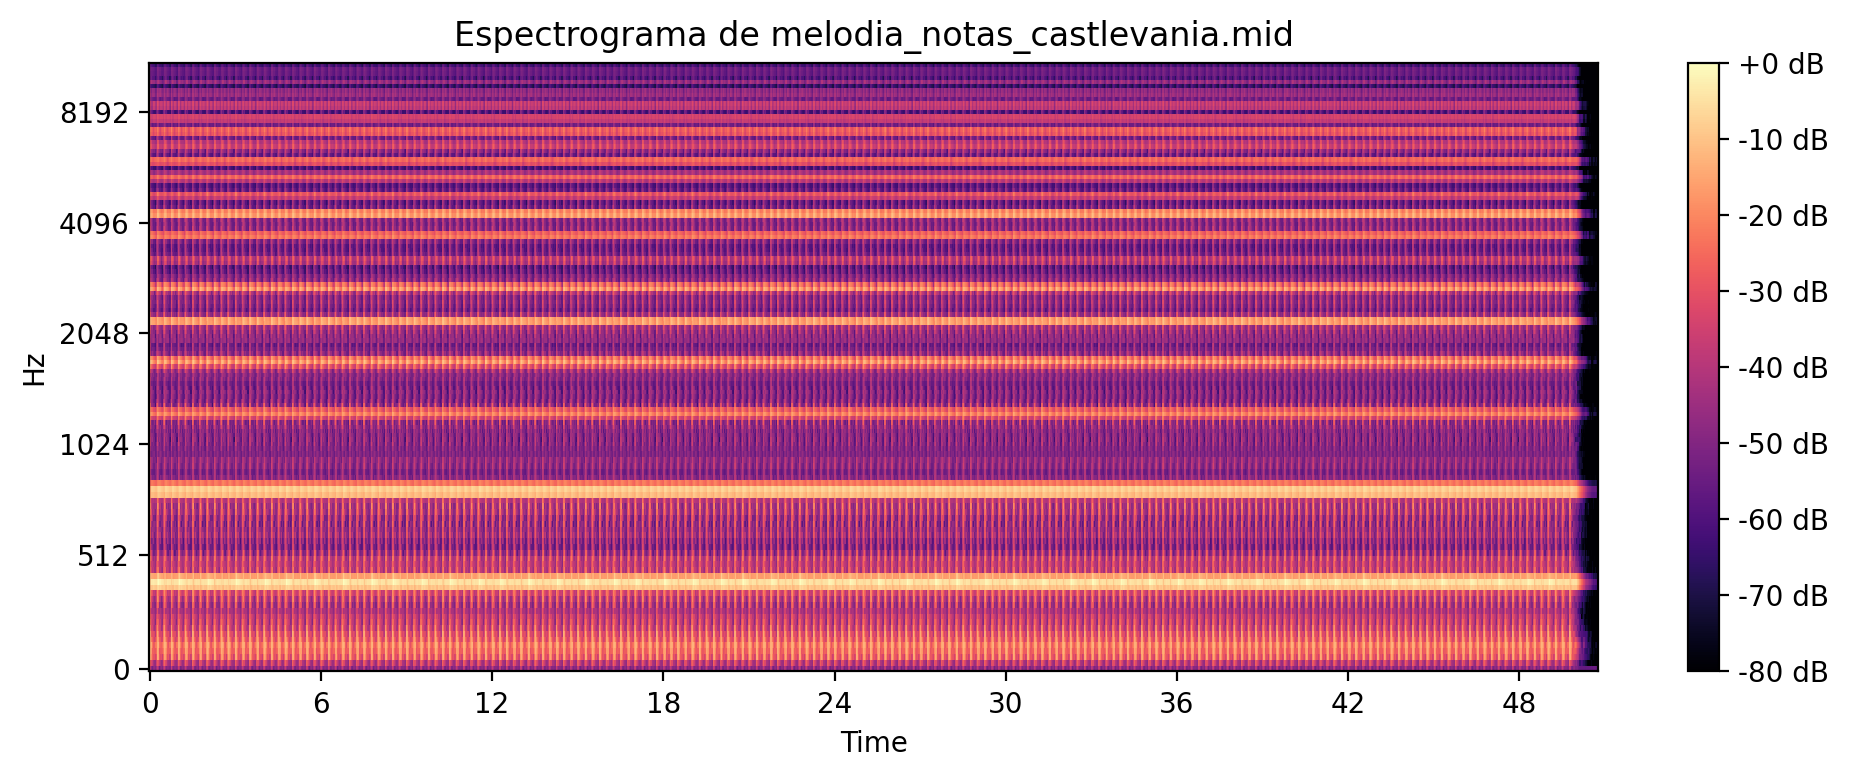

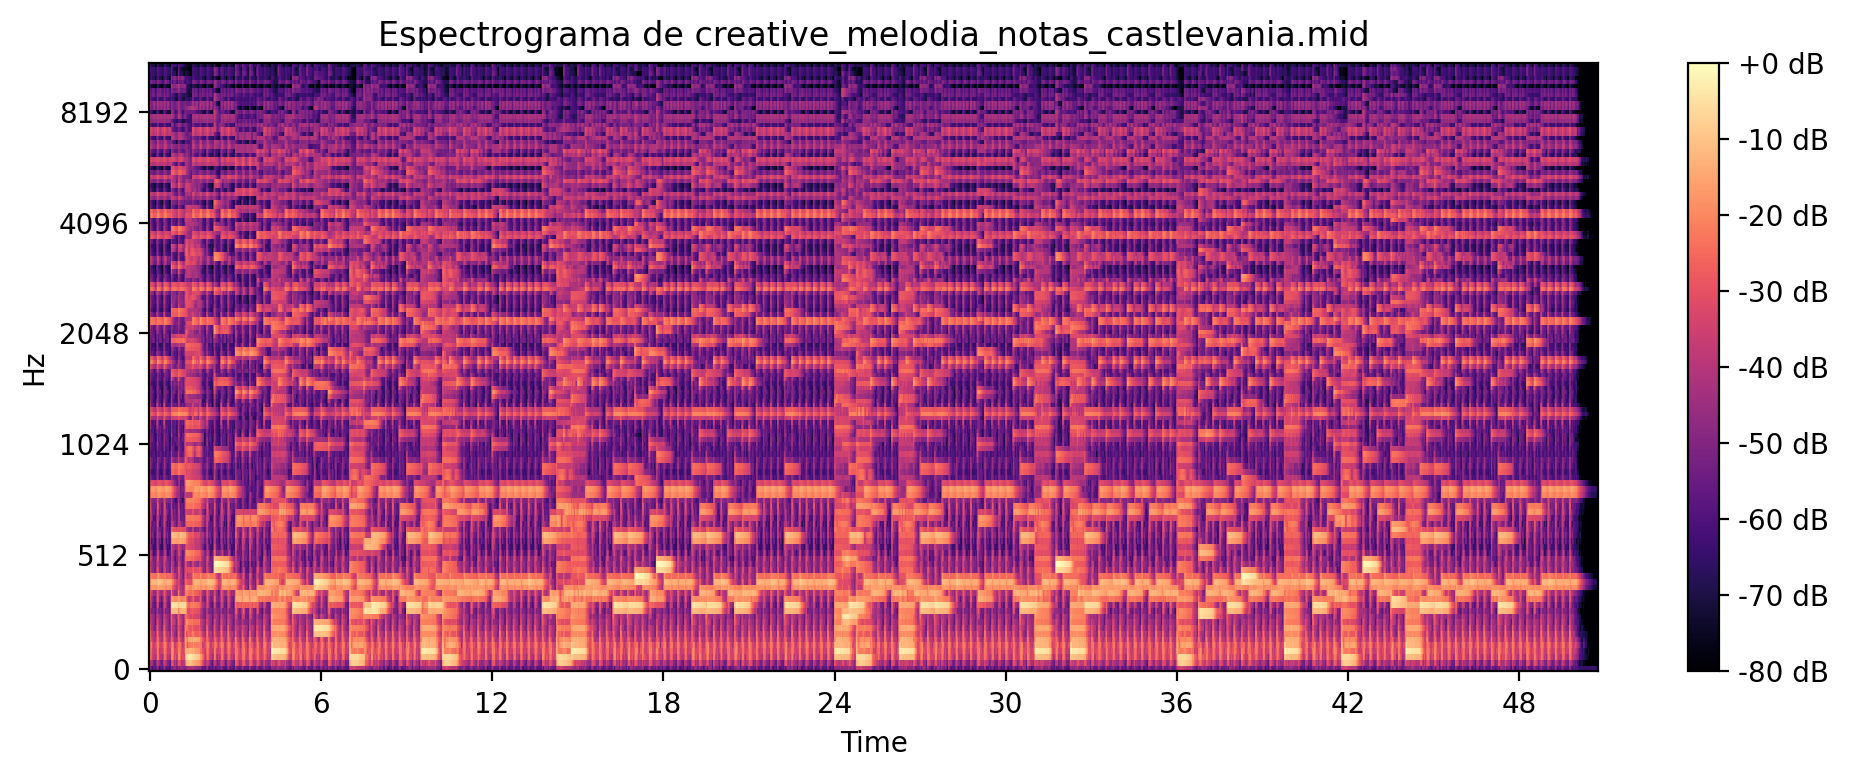

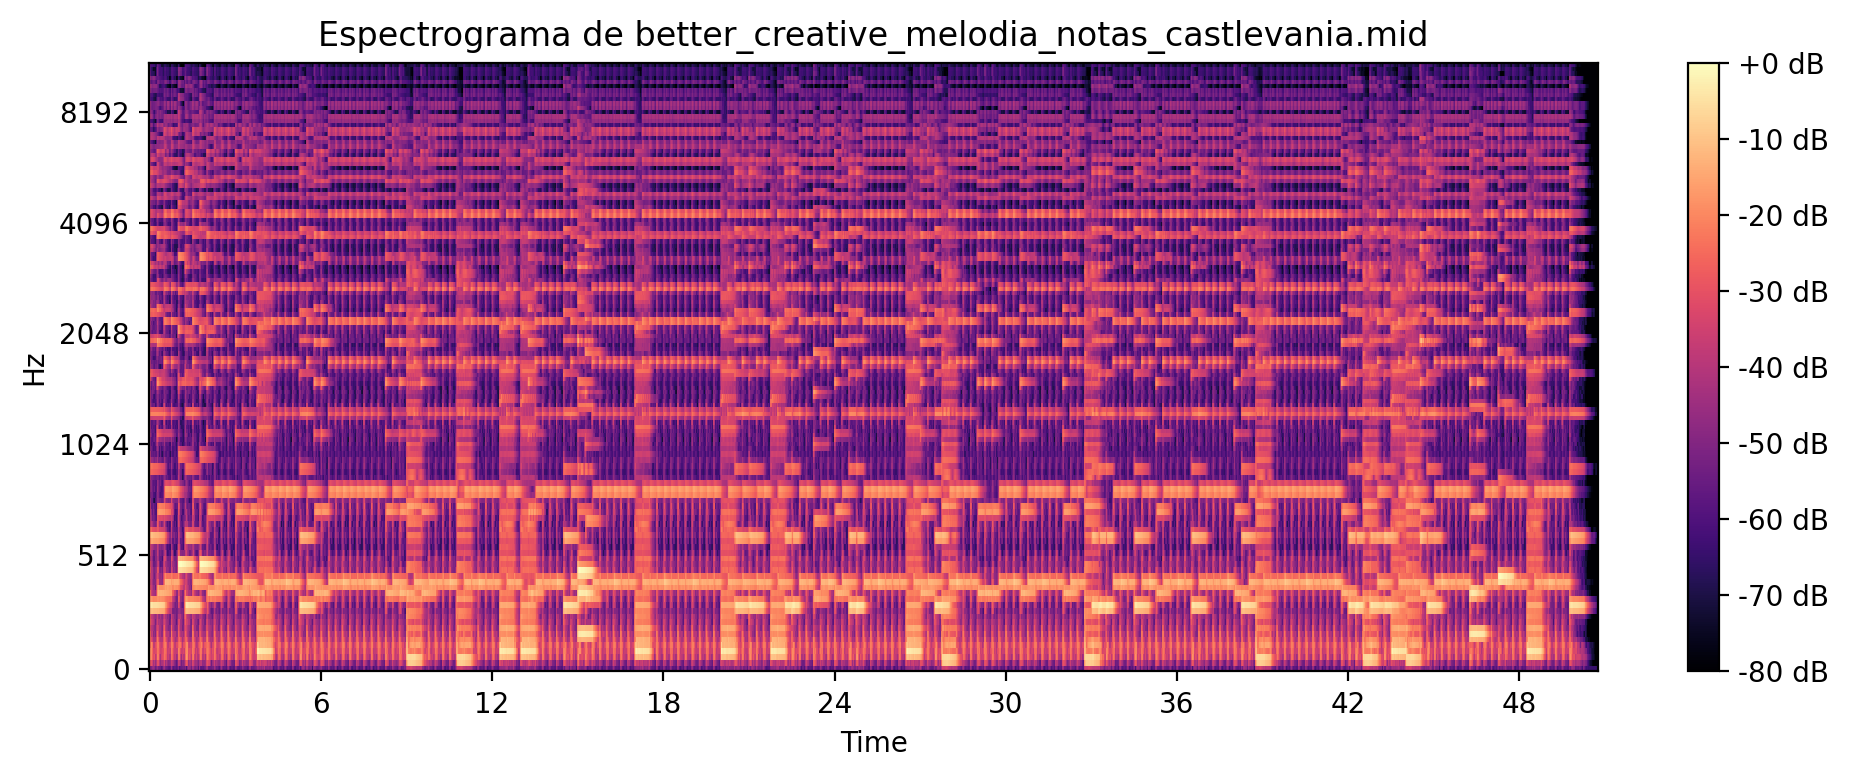

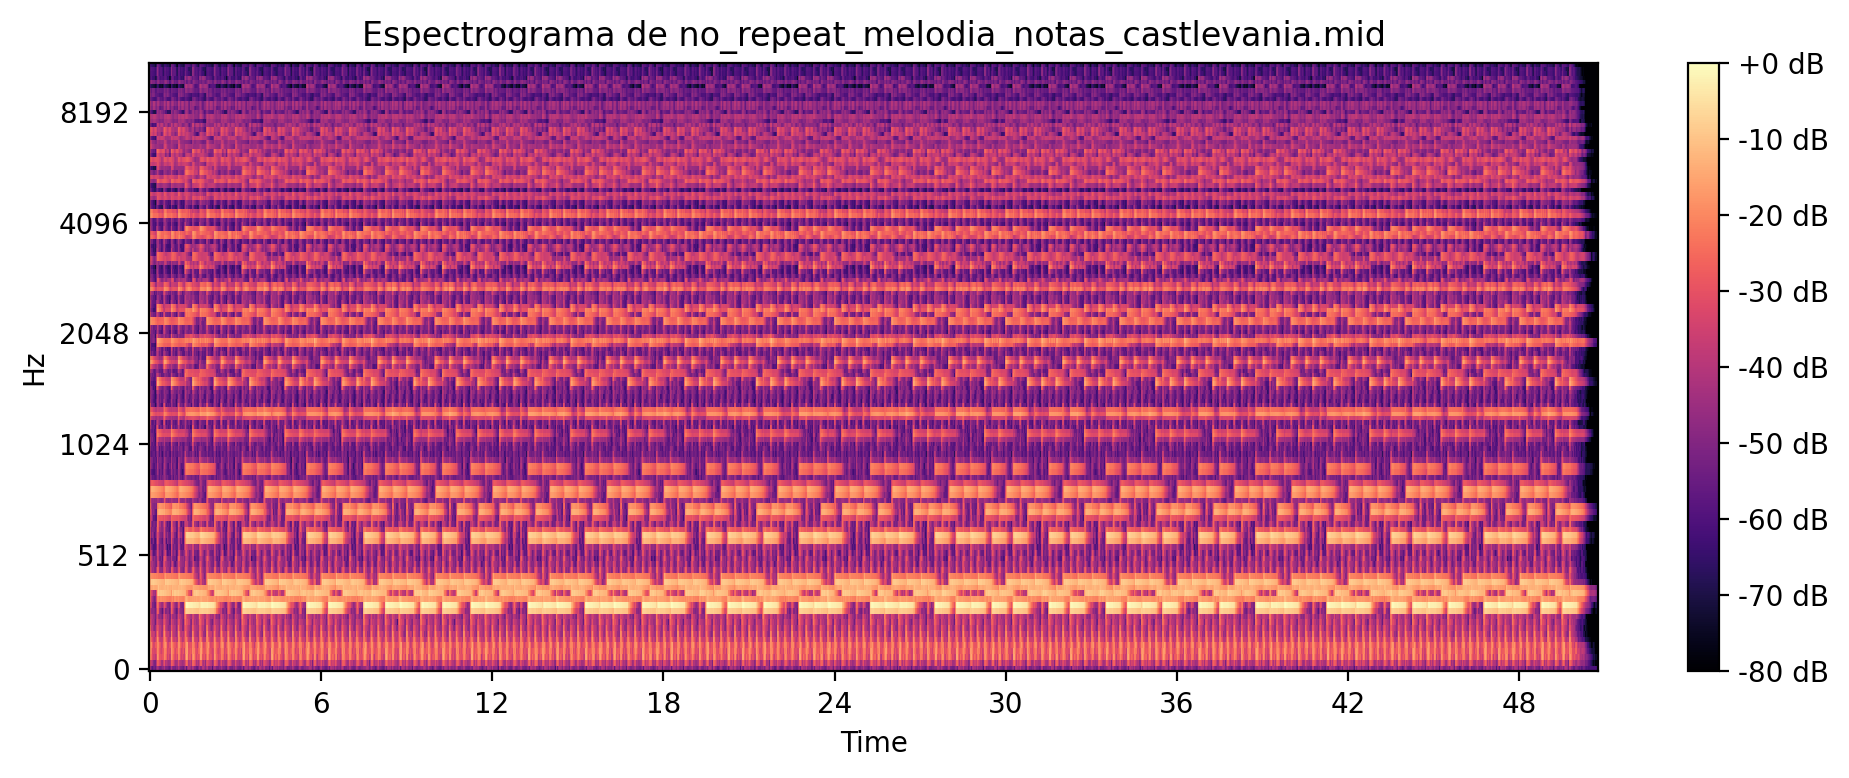

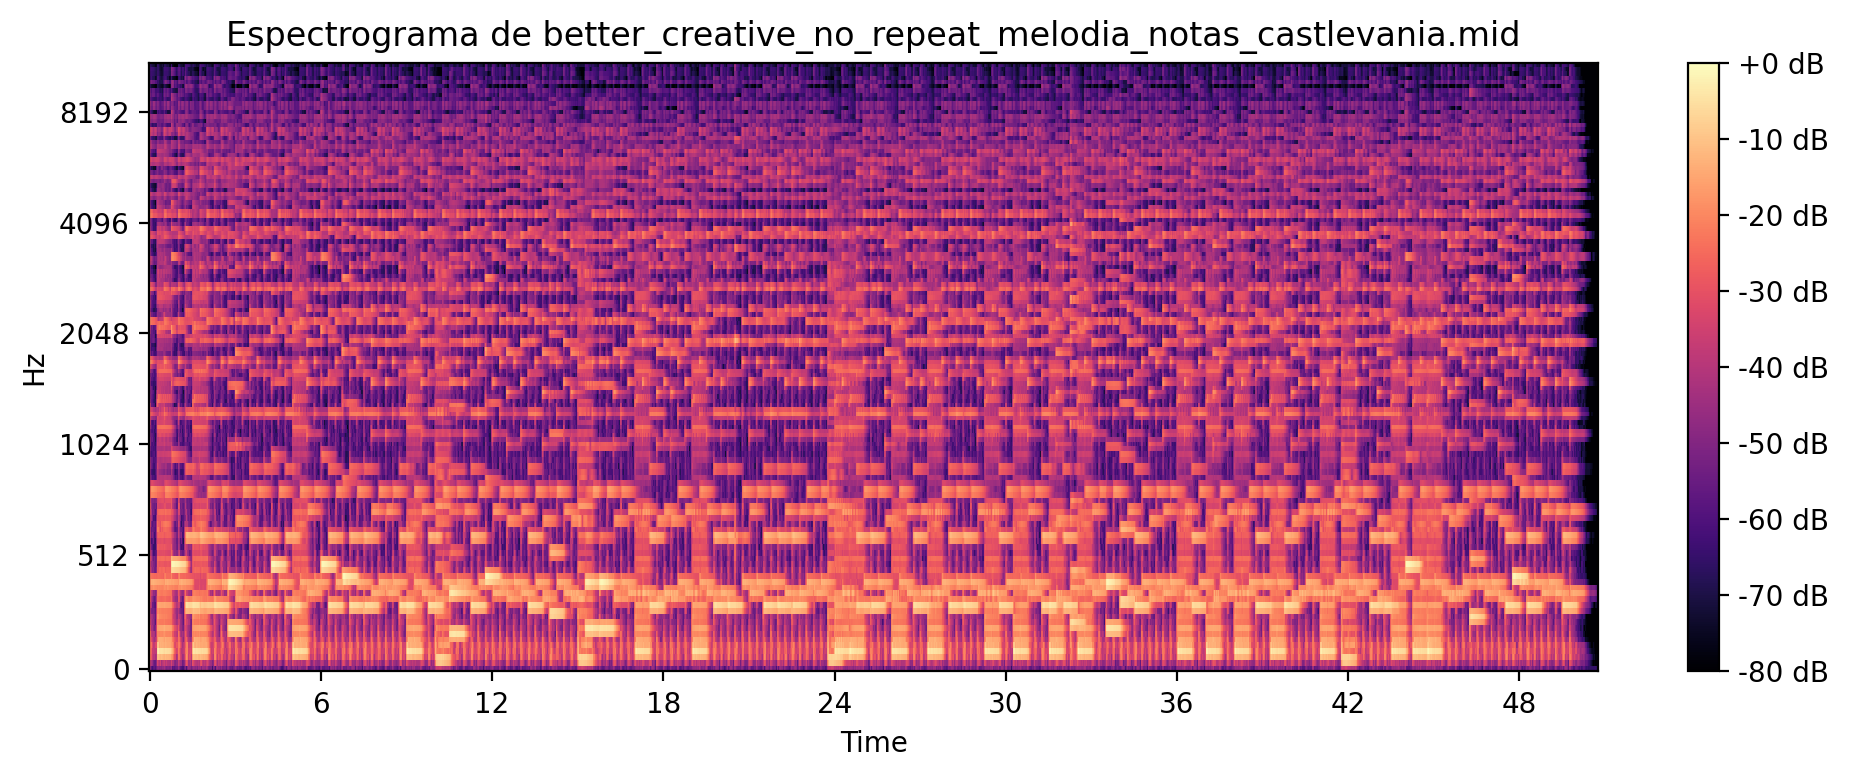

'/content/melody_project/output/better_creative_no_repeat_melodia_notas_castlevania.wav'

In [ ]:
resultados = generate_music("notas_castlevania", seed=42)
midi_to_wav_and_plot(resultados["normal"])
midi_to_wav_and_plot(resultados["creative"])
midi_to_wav_and_plot(resultados["better_creative"])
midi_to_wav_and_plot(resultados["no_repeat"])
midi_to_wav_and_plot(resultados["better_creative_no_repeat"])

##Volvemos a obtener nuestras melodías originales para comparar los espectogramas

In [ ]:
# Carpeta base del proyecto
BASE_DIR = Path("/content/melody_project")
DATA_DIR = BASE_DIR / "data"

midi_castlevania = DATA_DIR / "castlevania"

# Crear las carpetas, el for es super innecesario, soy consciente
for folder in [midi_castlevania]:
    folder.mkdir(parents=True, exist_ok=True)

print("Carpetas creadas:")
print(midi_castlevania)

Carpetas creadas:
/content/melody_project/data/castlevania


In [ ]:
from music21 import corpus, converter
from pathlib import Path
import requests

game_urls = {
    "castlevania0": "https://bitmidi.com/uploads/22418.mid",
    "castlevania1": "https://bitmidi.com/uploads/22419.mid",
    "castlevania2": "https://bitmidi.com/uploads/22420.mid",
    "castlevania3": "https://bitmidi.com/uploads/22421.mid",
    "castlevania4": "https://bitmidi.com/uploads/22422.mid",
    "castlevania5": "https://bitmidi.com/uploads/22423.mid",
    "castlevania6": "https://bitmidi.com/uploads/22424.mid",
    "castlevania7": "https://bitmidi.com/uploads/22425.mid",
    "castlevania8": "https://bitmidi.com/uploads/22426.mid",
    "castlevania9": "https://bitmidi.com/uploads/22427.mid",
    "castlevania10": "https://bitmidi.com/uploads/22428.mid",
    "castlevania11": "https://bitmidi.com/uploads/22429.mid",
    "castlevania12": "https://bitmidi.com/uploads/22430.mid",
    "castlevania13": "https://bitmidi.com/uploads/22431.mid",
    "castlevania14": "https://bitmidi.com/uploads/22432.mid",
    "castlevania15": "https://bitmidi.com/uploads/22433.mid",
    "castlevania16": "https://bitmidi.com/uploads/22434.mid",
    "castlevania17": "https://bitmidi.com/uploads/22435.mid",
    "castlevania18": "https://bitmidi.com/uploads/22436.mid",
    "castlevania19": "https://bitmidi.com/uploads/22437.mid",
    "castlevania20": "https://bitmidi.com/uploads/22438.mid",
    "castlevania21": "https://bitmidi.com/uploads/22439.mid",
    "castlevania22": "https://bitmidi.com/uploads/22440.mid",
    "castlevania23": "https://bitmidi.com/uploads/22441.mid",
    "castlevania24": "https://bitmidi.com/uploads/22442.mid",
    "castlevania25": "https://bitmidi.com/uploads/22443.mid",
    "castlevania26": "https://bitmidi.com/uploads/22444.mid",
    "castlevania27": "https://bitmidi.com/uploads/22445.mid",
    "castlevania28": "https://bitmidi.com/uploads/22446.mid",
    "castlevania29": "https://bitmidi.com/uploads/22447.mid",
    "castlevania30": "https://bitmidi.com/uploads/22448.mid",
    "castlevania31": "https://bitmidi.com/uploads/22449.mid",
    "castlevania32": "https://bitmidi.com/uploads/22450.mid",
    "castlevania33": "https://bitmidi.com/uploads/22451.mid",
    "castlevania34": "https://bitmidi.com/uploads/22452.mid",
    "castlevania35": "https://bitmidi.com/uploads/22453.mid",
    "castlevania36": "https://bitmidi.com/uploads/22454.mid",
    "castlevania37": "https://bitmidi.com/uploads/22455.mid",
    "castlevania38": "https://bitmidi.com/uploads/22456.mid",
    "castlevania39": "https://bitmidi.com/uploads/22457.mid",
    "castlevania40": "https://bitmidi.com/uploads/22458.mid",
    "castlevania41": "https://bitmidi.com/uploads/22459.mid",
    "castlevania42": "https://bitmidi.com/uploads/22460.mid",
    "castlevania43": "https://bitmidi.com/uploads/22461.mid",
    "castlevania44": "https://bitmidi.com/uploads/22462.mid",
    "castlevania45": "https://bitmidi.com/uploads/22463.mid",
    "castlevania46": "https://bitmidi.com/uploads/22464.mid",
    "castlevania47": "https://bitmidi.com/uploads/22465.mid",
    "castlevania48": "https://bitmidi.com/uploads/22466.mid",
    "castlevania49": "https://bitmidi.com/uploads/22467.mid",
    "castlevania50": "https://bitmidi.com/uploads/22468.mid",
    "castlevania51": "https://bitmidi.com/uploads/22469.mid",
    "castlevania52": "https://bitmidi.com/uploads/22470.mid",
    "castlevania53": "https://bitmidi.com/uploads/22471.mid",
    "castlevania54": "https://bitmidi.com/uploads/22472.mid",
    "castlevania55": "https://bitmidi.com/uploads/98089.mid",
    "castlevania56": "https://bitmidi.com/uploads/98090.mid",

}

headers = {"User-Agent": "Mozilla/5.0"}

for fname, url in game_urls.items():
    out_path = midi_castlevania / f"{fname}.mid"   # <<< ADD .mid EXTENSION
    print(f"Descargando {fname} desde {url}")
    try:
        r = requests.get(url, headers=headers, timeout=20)
        r.raise_for_status()
        with open(out_path, "wb") as f:
            f.write(r.content)
        print(f"Guardado: {fname}.mid")
    except Exception as e:
        print(f"Error descargando {fname}: {e}")

print("\nArchivos de castlevania listos en:")
!ls -lh {midi_castlevania}

Descargando castlevania0 desde https://bitmidi.com/uploads/22418.mid
Guardado: castlevania0.mid
Descargando castlevania1 desde https://bitmidi.com/uploads/22419.mid
Guardado: castlevania1.mid
Descargando castlevania2 desde https://bitmidi.com/uploads/22420.mid
Guardado: castlevania2.mid
Descargando castlevania3 desde https://bitmidi.com/uploads/22421.mid
Guardado: castlevania3.mid
Descargando castlevania4 desde https://bitmidi.com/uploads/22422.mid
Guardado: castlevania4.mid
Descargando castlevania5 desde https://bitmidi.com/uploads/22423.mid
Guardado: castlevania5.mid
Descargando castlevania6 desde https://bitmidi.com/uploads/22424.mid
Guardado: castlevania6.mid
Descargando castlevania7 desde https://bitmidi.com/uploads/22425.mid
Guardado: castlevania7.mid
Descargando castlevania8 desde https://bitmidi.com/uploads/22426.mid
Guardado: castlevania8.mid
Descargando castlevania9 desde https://bitmidi.com/uploads/22427.mid
Guardado: castlevania9.mid
Descargando castlevania10 desde https://

##Comparar entre los espectogramas generados y los de entrenamientos

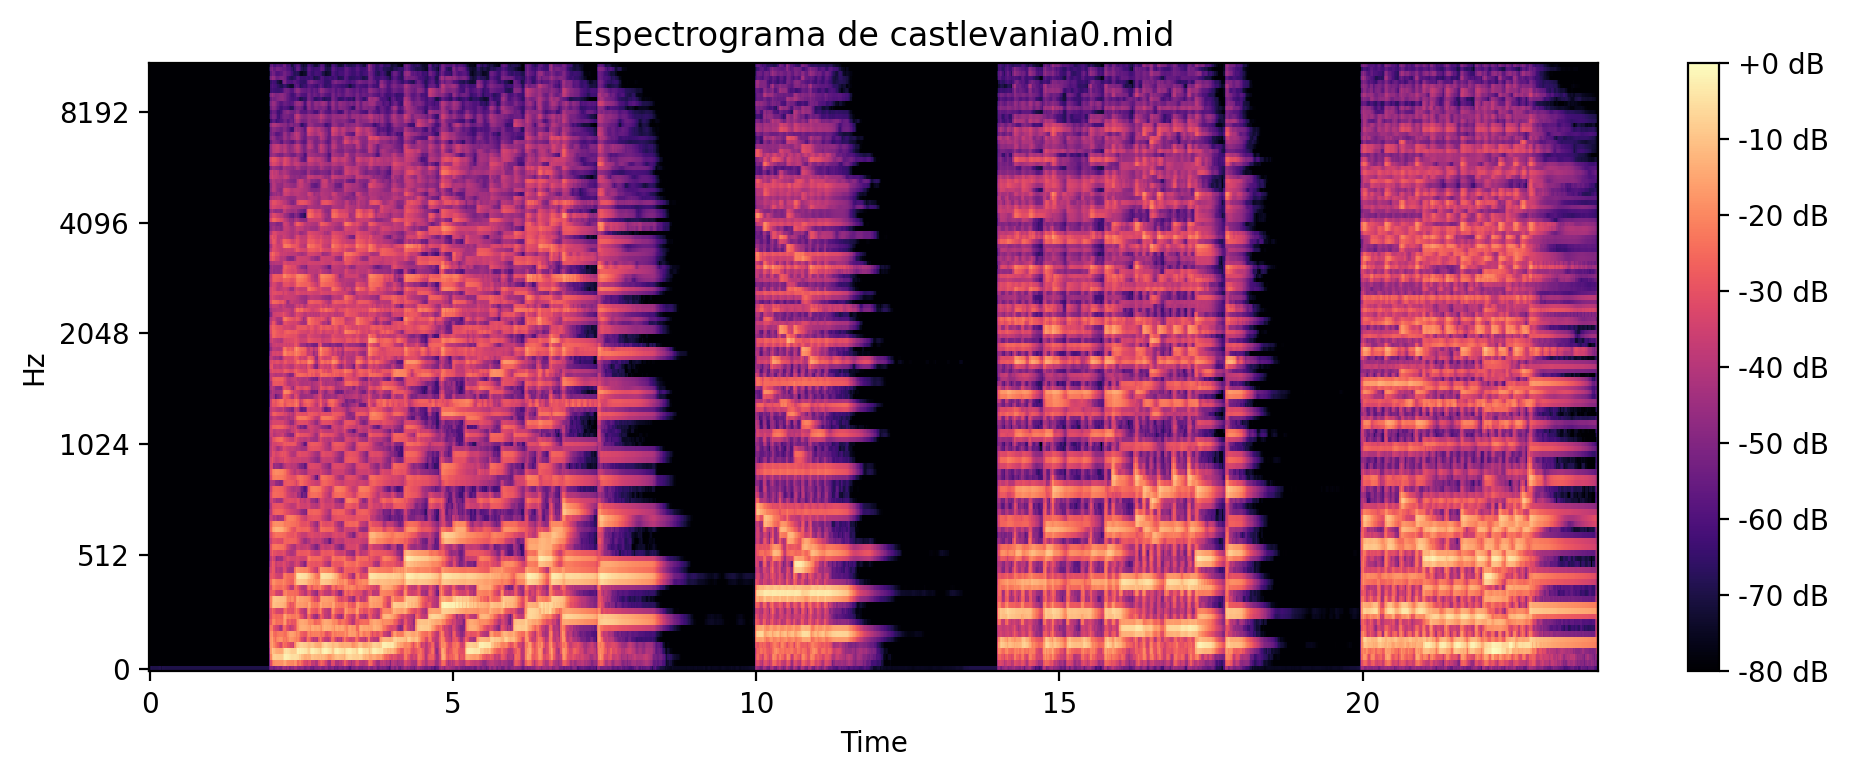

'/content/melody_project/data/castlevania/castlevania0.wav'

In [ ]:
midi_to_wav_and_plot("/content/melody_project/data/castlevania/castlevania0.mid")

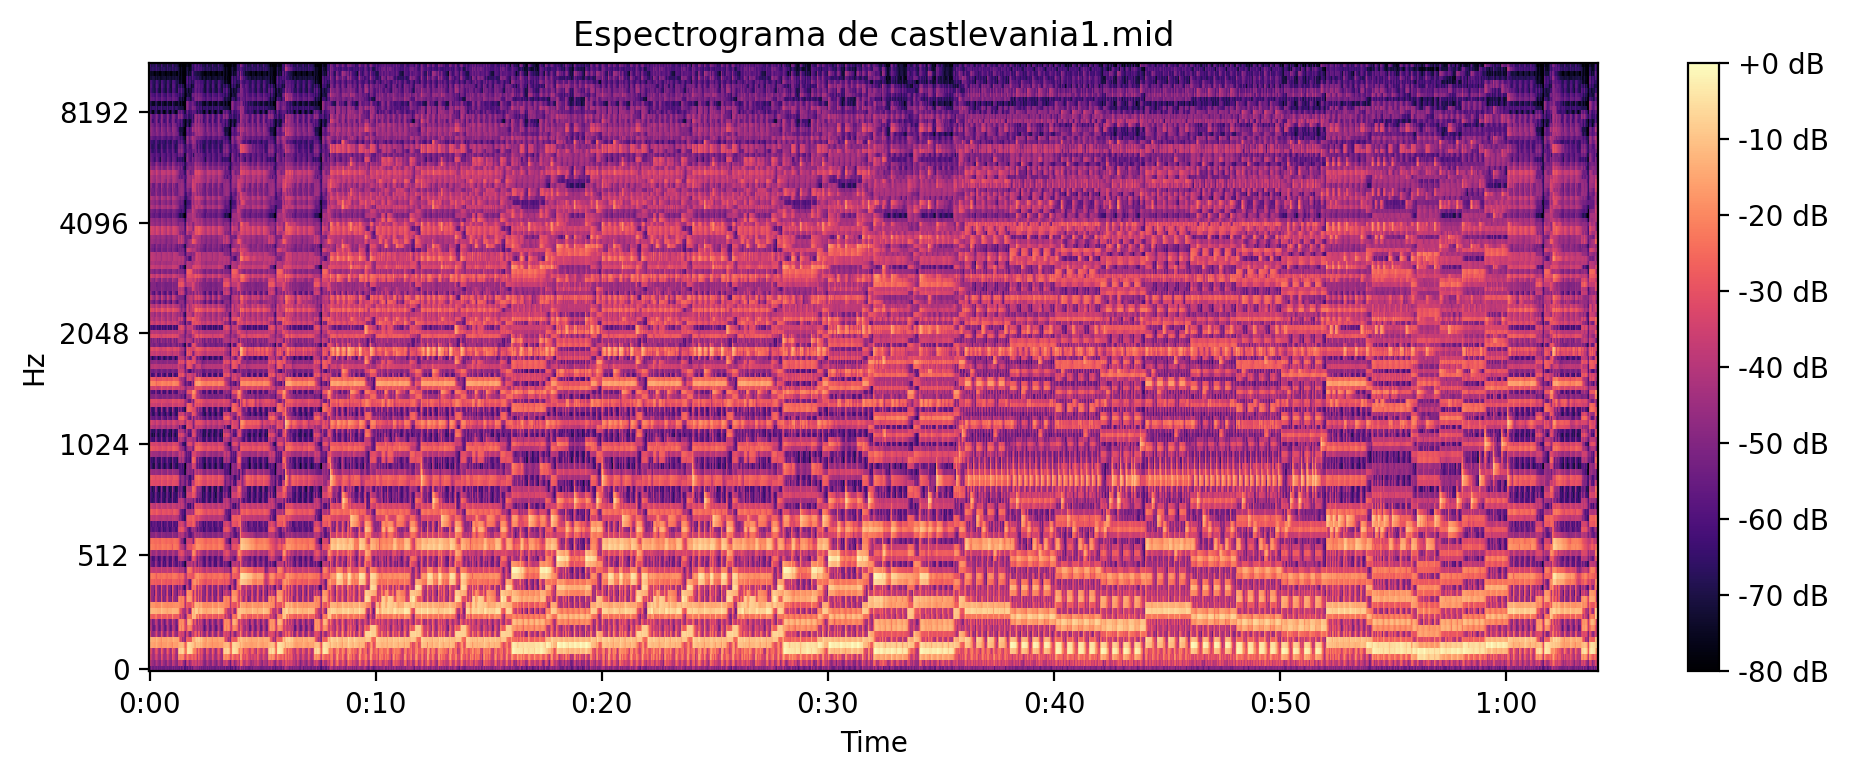

'/content/melody_project/data/castlevania/castlevania1.wav'

In [ ]:
midi_to_wav_and_plot("/content/melody_project/data/castlevania/castlevania1.mid")

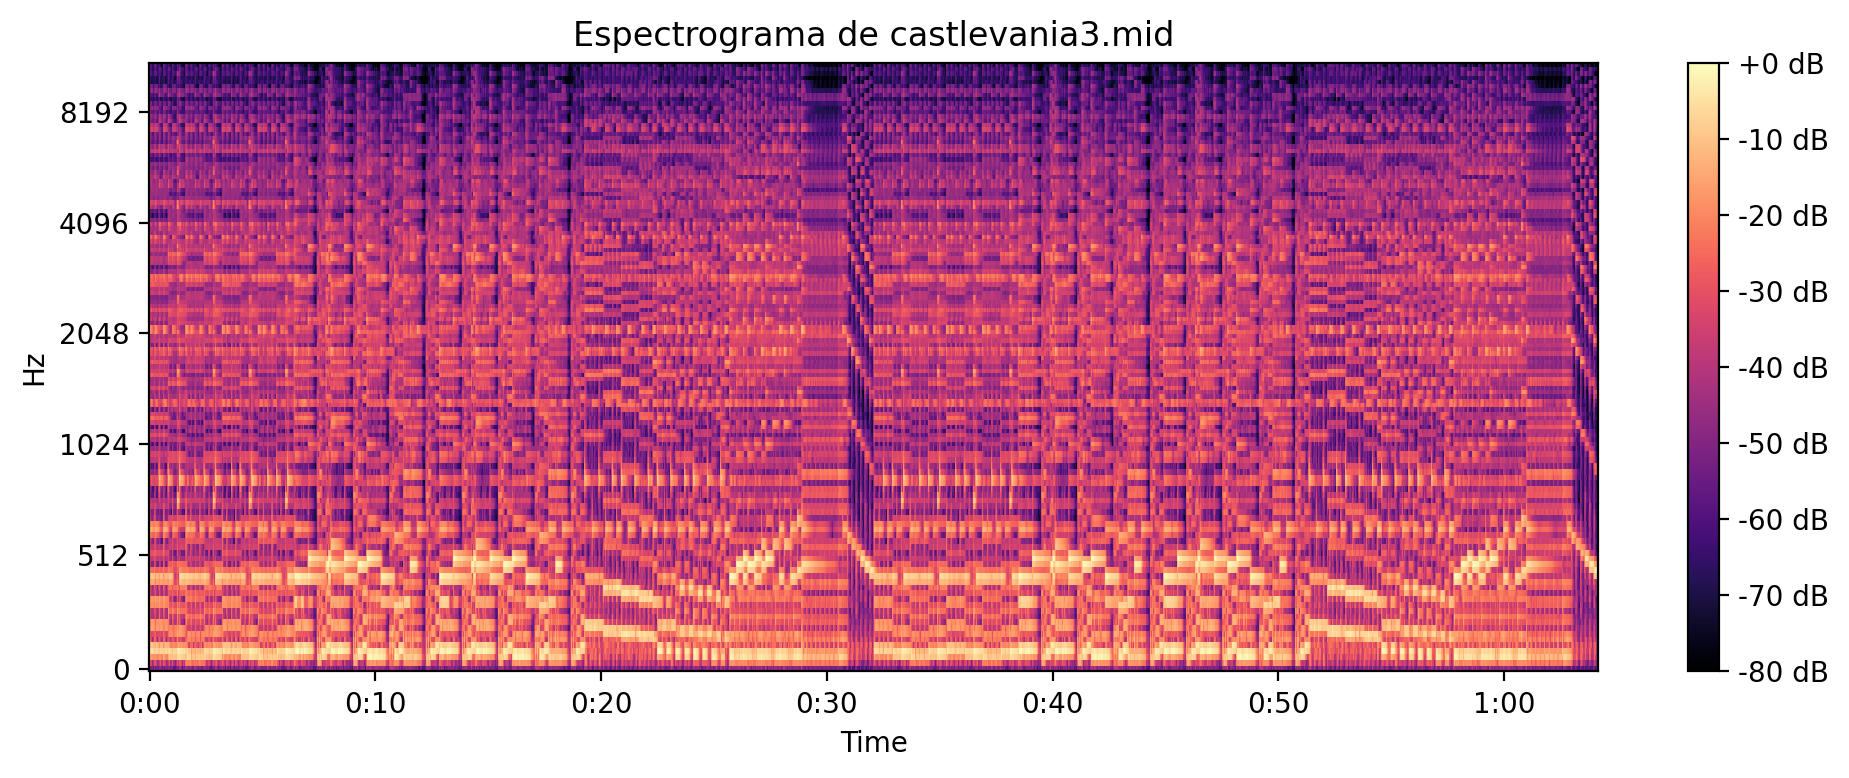

'/content/melody_project/data/castlevania/castlevania3.wav'

In [ ]:
midi_to_wav_and_plot("/content/melody_project/data/castlevania/castlevania3.mid")

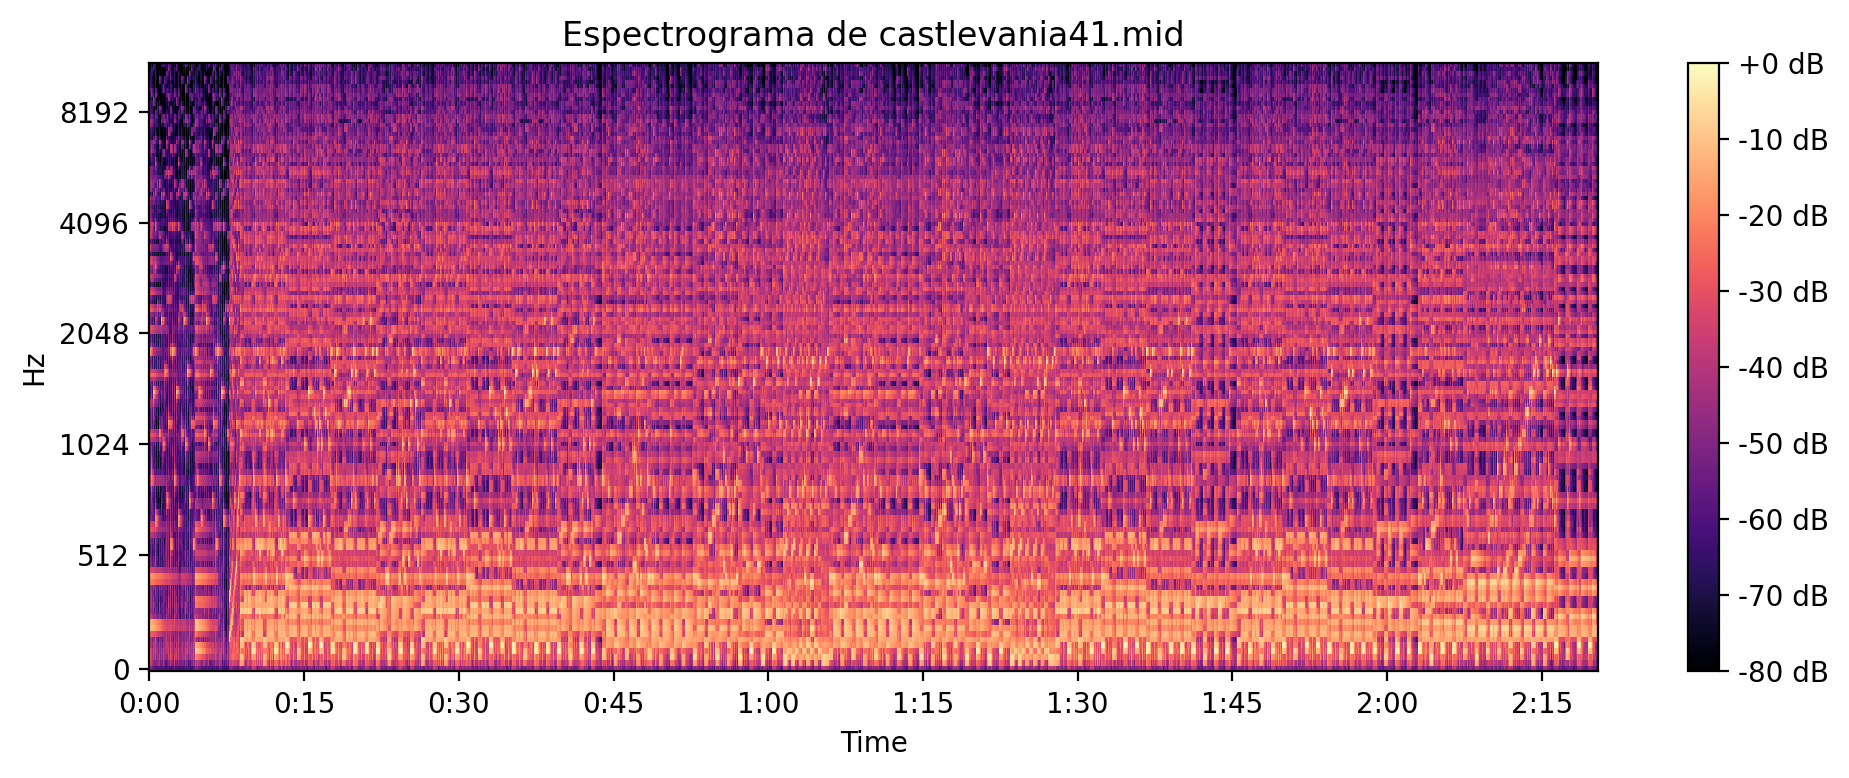

'/content/melody_project/data/castlevania/castlevania41.wav'

In [ ]:
midi_to_wav_and_plot("/content/melody_project/data/castlevania/castlevania41.mid")

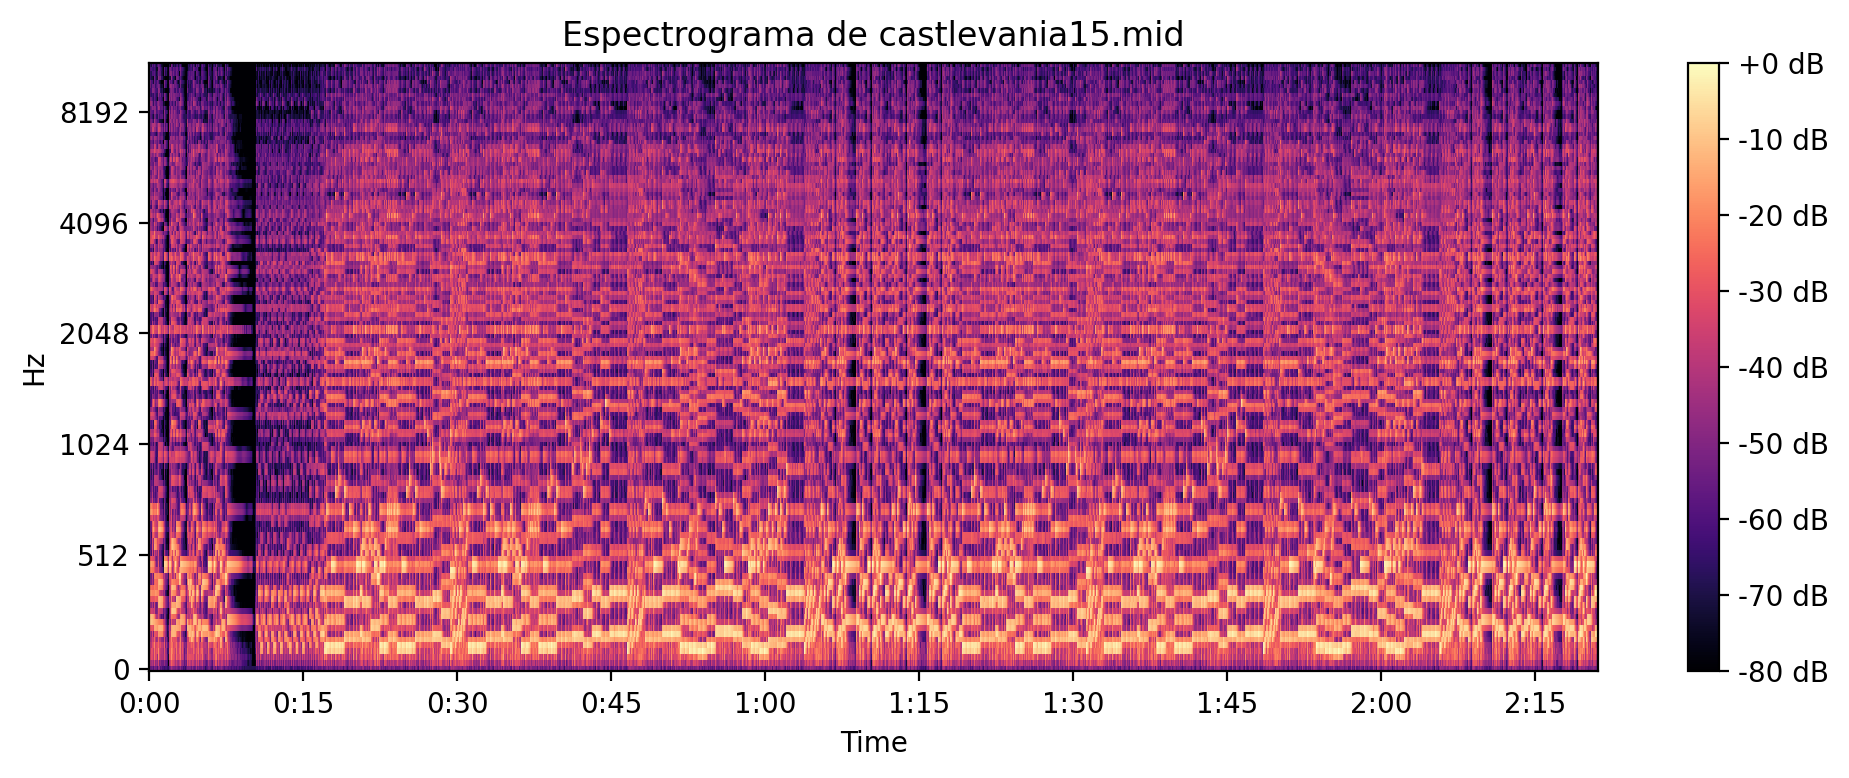

'/content/melody_project/data/castlevania/castlevania15.wav'

In [ ]:
midi_to_wav_and_plot("/content/melody_project/data/castlevania/castlevania15.mid")

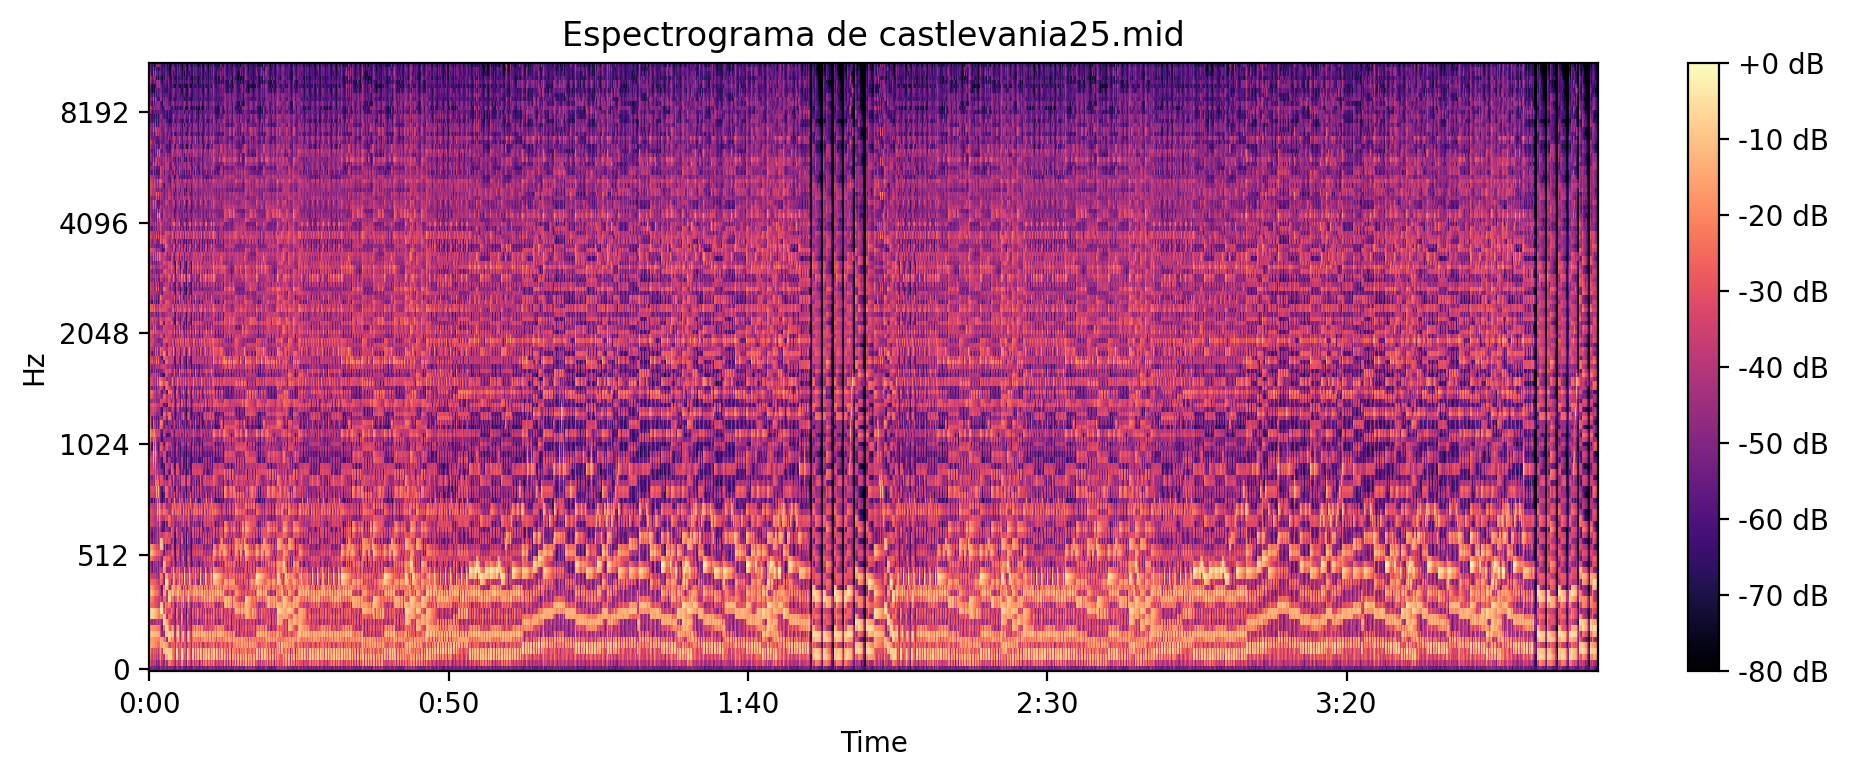

'/content/melody_project/data/castlevania/castlevania25.wav'

In [ ]:
midi_to_wav_and_plot("/content/melody_project/data/castlevania/castlevania25.mid")

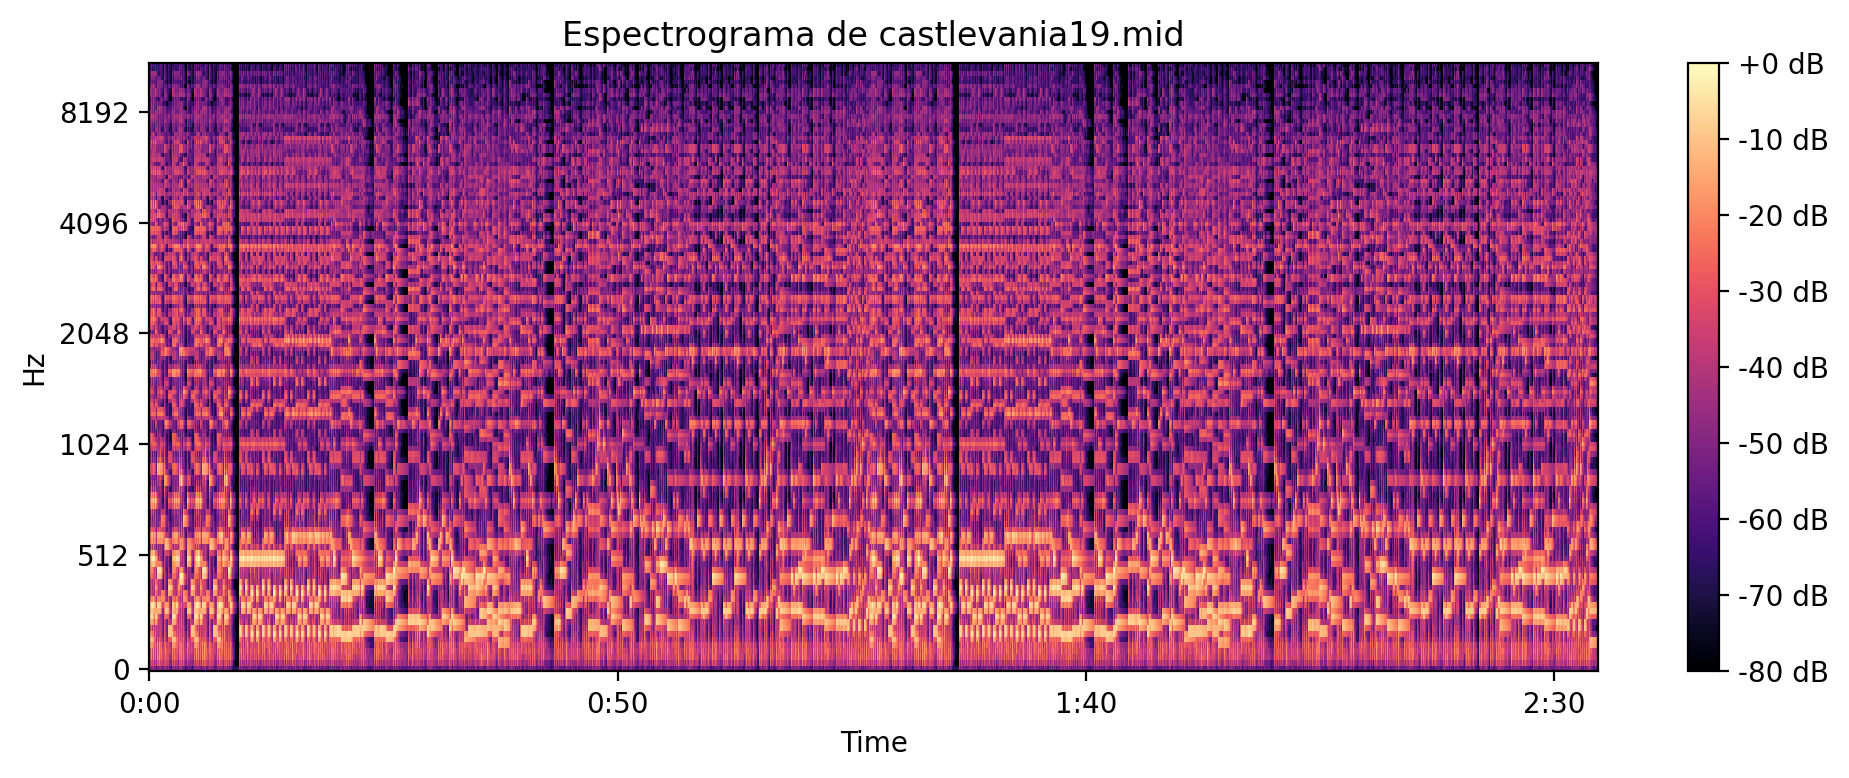

'/content/melody_project/data/castlevania/castlevania19.wav'

In [ ]:
midi_to_wav_and_plot("/content/melody_project/data/castlevania/castlevania19.mid")